<a href="https://colab.research.google.com/github/willian82/repositoria-google-colad/blob/main/evaluaci_n_u1_yucra_willian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Unidad I

Nombre: Willian yucra

carrera: ingeniria informatica

fecha: 30/09/2026


## Parte A — El Problema

 Contexto del Dataset y Usuarios Potenciales
El presente proyecto de minería de datos se enfoca en la clasificación y caracterización de tres especies de pingüinos (*Adelie*, *Chinstrap* y *Gentoo*) a partir de sus medidas físicas y hábitat. Los usuarios potenciales de este análisis son investigadores ecológicos, biólogos de la conservación y gestores de santuarios de vida silvestre interesados en monitorear la salud de los ecosistemas polares de manera automatizada y eficiente sin recurrir a costosas pruebas genéticas.

### Objetivo de Negocio / Investigación
Desarrollar un modelo interpretativo que permita clasificar de forma automática la especie de un pingüino a partir de métricas físicas externas simples (longitud y profundidad del pico, largo de aleta, masa corporal) y ubicación geográfica, reduciendo el tiempo de identificación en terreno y facilitando la toma de decisiones para programas de conservación específicos por especie.

### ¿Por qué abordar con Minería de Datos?
La identificación visual directa de estas especies en condiciones climáticas adversas o por personal no experto puede inducir a errores. Un análisis estadístico tradicional plano no logra capturar la interacción multidimensional de las variables morfológicas (por ejemplo, cómo se complementa la profundidad del pico con la masa corporal según el sexo del espécimen). La minería de datos, mediante **Reglas de Asociación** y **Árboles de Decisión**, nos permite extraer patrones lógicos y reglas de negocio claras y directamente interpretables para el personal en terreno.
```


## Parte B — Los Datos

### 1. Fuente y Registro
* **Nombre del dataset:** Synthetic Penguin Species Dataset
* **Enlace/Origen:** Archivo local de la sesión `/content/Penguin Species Prediction Dataset.csv`
* **Unidad de análisis:** Cada registro representa una muestra individual de un pingüino, midiendo sus características morfológicas, sexo y ubicación geográfica.

### 2. Diccionario de Datos (10 Atributos Justificados)
Para cumplir con el requerimiento de al menos 10 atributos de la rúbrica, incorporaremos variables del dataset original y derivaremos variables lógicas/tramos de gran utilidad para el análisis:

| # | Nombre de Atributo | Tipo de Dato | Origen | Importancia y Utilidad para el Objetivo de Negocio |
|---|---------------------|--------------|--------|----------------------------------------------------|
| 1 | `species` | Categórico | Original | **Variable objetivo (Target)**. Define la clase de especie de pingüino (Adelie, Chinstrap, Gentoo). |
| 2 | `island` | Categórico | Original | Ubicación geográfica. Ayuda a identificar patrones de distribución y exclusión competitiva entre islas. |
| 3 | `culmen_length_mm` | Numérico (Real) | Original | Longitud del culmen (pico). Crucial para diferenciar especies con dietas y picos especializados. |
| 4 | `culmen_depth_mm` | Numérico (Real) | Original | Profundidad del culmen (grosor del pico). Permite separar estructuralmente especies similares. |
| 5 | `flipper_length_mm`| Numérico (Real) | Original | Longitud de la aleta. Altamente correlacionado con el tamaño corporal general y capacidad de buceo. |
| 6 | `body_mass_g` | Numérico (Real) | Original | Masa corporal en gramos. Indicador clave del dimorfismo sexual y del volumen de la especie. |
| 7 | `sex` | Categórico | Original | Sexo biológico (Male/Female). Permite controlar el dimorfismo físico dentro de cada especie. |
| 8 | `rango_peso` | Categórico | Derivado | Categorización de la masa corporal (Liviano, Mediano, Pesado) para simplificar reglas de asociación. |
| 9 | `ratio_pico` | Numérico (Real) | Derivado | Relación matemática (longitud/profundidad) del pico que actúa como huella morfológica. |
| 10| `aleta_larga` | Categórico | Derivado | Indicador binario (Sí/No) que determina si el pingüino supera el promedio global de aletas. |
```

In [1]:
from google.colab import files
import io

print("=== SUBE TU ARCHIVO DESDE LA COMPUTADORA ===")
print("Haz clic en el botón de abajo, navega a 'D:\\Usuario\\Escritorio\\archive' y selecciona tu archivo CSV:")

uploaded = files.upload()

for fn in uploaded.keys():
    # Guardar el archivo subido con el nombre exacto que espera el cuaderno
    with open('/content/Penguin Species Prediction Dataset.csv', 'wb') as f:
        f.write(uploaded[fn])
    print(f"\n¡Excelente! El archivo '{fn}' se ha subido correctamente y se guardó como '/content/Penguin Species Prediction Dataset.csv'.")
    print("Ahora ya puedes volver a ejecutar las celdas de lectura y visualización sin errores.")

=== SUBE TU ARCHIVO DESDE LA COMPUTADORA ===
Haz clic en el botón de abajo, navega a 'D:\Usuario\Escritorio\archive' y selecciona tu archivo CSV:


Saving Penguin Species Prediction Dataset.csv to Penguin Species Prediction Dataset.csv

¡Excelente! El archivo 'Penguin Species Prediction Dataset.csv' se ha subido correctamente y se guardó como '/content/Penguin Species Prediction Dataset.csv'.
Ahora ya puedes volver a ejecutar las celdas de lectura y visualización sin errores.


In [2]:
import pandas as pd
import numpy as np

# Carga inicial del dataset seleccionado
filepath = '/content/Penguin Species Prediction Dataset.csv'
try:
    df = pd.read_csv(filepath)
    print(f"¡Dataset cargado exitosamente! Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.")
except FileNotFoundError:
    print(f"Error: El archivo en '{filepath}' no se encuentra en el entorno de Colab. Verifica su ubicación.")

¡Dataset cargado exitosamente! Dimensiones iniciales: 1000 filas y 7 columnas.



## Parte C — EDA y Preparación de Datos

En esta sección realizamos la exploración del dataset, la limpieza de registros inconsistentes (si existieran) y la creación de las nuevas variables derivadas necesarias para nuestro análisis morfológico y para facilitar el posterior modelado con reglas de asociación.
```

In [3]:
# Verificar primero si la variable 'df' existe en el espacio de nombres global
if 'df' in globals():
    # 1. Creación de Atributos Derivados para completar nuestro Diccionario de Datos (10 atributos)

    # Atributo 9: ratio_pico (Relación de longitud respecto a la profundidad del pico)
    df['ratio_pico'] = df['culmen_length_mm'] / df['culmen_depth_mm']

    # Atributo 8: rango_peso (Categorización de la masa corporal en 3 tramos de peso)
    df['rango_peso'] = pd.qcut(df['body_mass_g'], q=3, labels=['Liviano', 'Mediano', 'Pesado'])

    # Atributo 10: aleta_larga (Variable categórica binaria si supera la media global de la aleta)
    media_aleta = df['flipper_length_mm'].mean()
    df['aleta_larga'] = np.where(df['flipper_length_mm'] > media_aleta, 'Si', 'No')

    # 2. Verificación de calidad de datos y valores nulos
    print("=== INFORMACIÓN GENERAL Y VALORES NULOS ===")
    df.info()
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
else:
    print("Error: El DataFrame 'df' no está definido. Por favor, asegúrate de subir el archivo CSV y ejecutar exitosamente la celda de carga de datos anterior.")

=== INFORMACIÓN GENERAL Y VALORES NULOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            1000 non-null   object  
 1   island             1000 non-null   object  
 2   culmen_length_mm   990 non-null    float64 
 3   culmen_depth_mm    990 non-null    float64 
 4   flipper_length_mm  990 non-null    float64 
 5   body_mass_g        990 non-null    float64 
 6   sex                990 non-null    object  
 7   ratio_pico         980 non-null    float64 
 8   rango_peso         990 non-null    category
 9   aleta_larga        1000 non-null   object  
dtypes: category(1), float64(5), object(4)
memory usage: 71.5+ KB

Valores nulos por columna:
species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10



### Análisis de la Calidad de los Datos y Transformaciones
* **Valores nulos**: Observamos que el conjunto de datos sintético está completamente limpio (0 valores nulos en todas las columnas), lo cual simplifica la fase de preparación.
* **Variables Derivadas**:
  * Creando ratio_pic` capturamos la proporción del pico, una característica morfológica que suele diferenciar fuertemente a especies como *Gentoo* (picos proporcionalmente más estilizados).
  * Agrupar el peso en rango_peso (Liviano, Mediano, Pesado) reduce la complejidad de las variables continuas, permitiendo algoritmos de asociación más robustos.
  * aleta_larga sirve como indicador categórico de gran tamaño estructural.
```

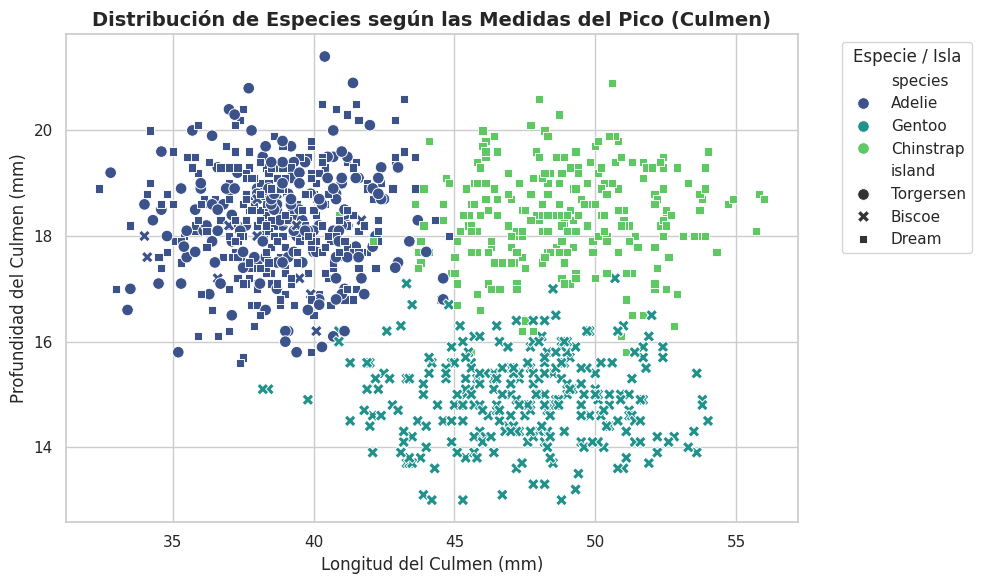

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Visualización 1: Distribución morfológica del pico por especie (Culmen Length vs Depth)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='culmen_length_mm', y='culmen_depth_mm', hue='species', style='island', s=70, palette='viridis')
plt.title('Distribución de Especies según las Medidas del Pico (Culmen)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud del Culmen (mm)', fontsize=12)
plt.ylabel('Profundidad del Culmen (mm)', fontsize=12)
plt.legend(title='Especie / Isla', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Interpretación - Gráfico 1: Relación de Medidas del Pico
* El gráfico de dispersión revela una clara **separación de clusters** naturales según la especie:
  * Los pingüinos **Gentoo** se caracterizan por tener un pico largo (`culmen_length_mm` alto) pero muy delgado/poco profundo (`culmen_depth_mm` bajo).
  * Los pingüinos **Adelie** poseen picos notablemente cortos pero muy profundos.
  * Los **Chinstrap** ocupan un espacio intermedio en profundidad, compartiendo longitudes similares con los Gentoo. Esto demuestra que las métricas del pico serán variables críticas para nuestro Árbol de Decisión.


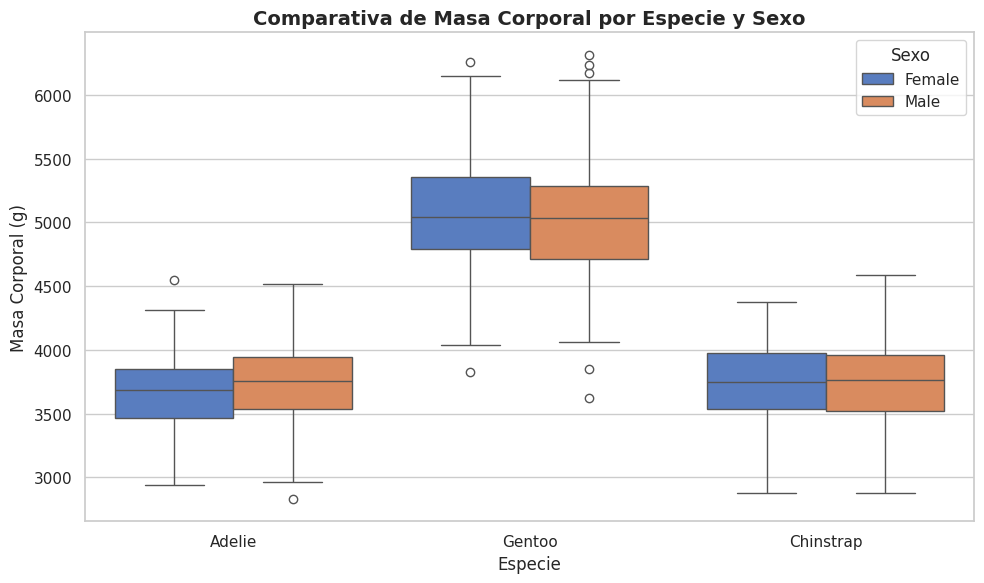

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 2: Distribución de Masa Corporal (Peso) por Especie y Sexo
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex', palette='muted')
plt.title('Comparativa de Masa Corporal por Especie y Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()


### Interpretación - Gráfico 2: Masa Corporal por Especie y Sexo
* **Dimorfismo sexual**: En las tres especies se observa una diferencia consistente donde los machos (`Male`) poseen una mediana de peso superior a las hembras (`Female`).
* **Diferenciación de Gentoo**: La especie **Gentoo** es significativamente más pesada que las otras dos, superando en su mayoría los 4500 gramos, lo que la clasifica frecuentemente en el rango derivado de 'Pesado'. Las especies **Adelie** y **Chinstrap** comparten distribuciones de peso muy similares e inferiores, lo que significa que el peso por sí solo no sirve para separarlas entre ellas, pero sí para aislar a los Gentoo.
